In [2]:
print("AI Freight forecasting project started")

AI Freight forecasting project started


In [3]:
%pip install pandas numpy scikit-learn matplotlib seaborn ipywidgets

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
%pip install prophet requests

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Time-ordered validation MAE: $1.15/tonne (illustrative demo data)
status                                                  OK
recommended_vessel                                Supramax
market_entry             Layer a multi-voyage contract now
contract_months                                          3
rate_usd_per_ton                                     67.62
estimated_freight_usd                            3380960.0
estimated_port_days                                    3.9
dtype: object
Warnings: No immediate threshold warning

Vessel comparison:


,vessel_type,average_rate,first_month_rate,rate_trend,load_days,unload_days
0,Supramax,67.62,66.54,0.82,2.78,1.11
1,Panamax,67.87,66.77,0.88,2.27,1.11
2,Capesize,70.76,69.43,1.25,1.67,1.11


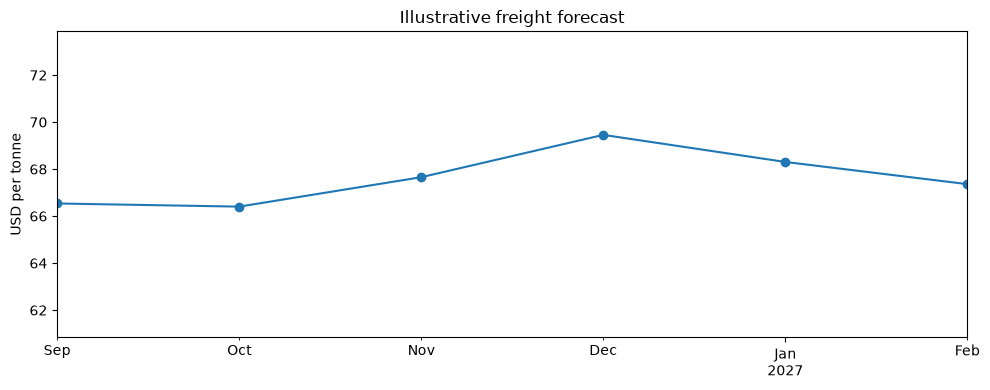


Production inputs to connect next: verified fixture/berth limits, historical fixtures, commodity and macro feeds, and live congestion ETAs.


In [6]:
# Freight forecasting and chartering decision support baseline
# Replace the synthetic history with an operations-approved freight-rate feed before production use.
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

RANDOM_STATE = 42

ORIGINS = {
    "Australia": {"distance_nm": 3500, "base_rate": 22, "seasonality": 2.0},
    "US": {"distance_nm": 10500, "base_rate": 34, "seasonality": 3.5},
    "Mozambique": {"distance_nm": 4300, "base_rate": 25, "seasonality": 2.5},
    "Russia": {"distance_nm": 6200, "base_rate": 29, "seasonality": 3.0},
    "Indonesia": {"distance_nm": 2800, "base_rate": 19, "seasonality": 1.8},
}

# Illustrative operating limits. Validate against current berth, channel and terminal data.
PORT_LIMITS = pd.DataFrame([
    ["Paradip", 290, 45, 18.0, 45000, 65000],
    ["Vizag", 245, 40, 16.5, 40000, 55000],
    ["Gangavaram", 300, 50, 18.5, 55000, 80000],
    ["Gopalpur", 220, 36, 14.0, 25000, 40000],
    ["Dhamra", 285, 45, 18.0, 45000, 70000],
    ["Sagar-Sandheads", 230, 38, 14.5, 30000, 45000],
    ["Haldia", 210, 32, 10.5, 25000, 35000],
], columns=["port", "max_loa_m", "max_beam_m", "max_draft_m", "handling_tpd", "annual_capacity_mt"])

VESSELS = pd.DataFrame([
    ["Handysize", 30000, 190, 32, 10.5, 12000, 10500],
    ["Supramax", 55000, 200, 32, 12.5, 18000, 14500],
    ["Panamax", 75000, 225, 32, 14.5, 22000, 18500],
    ["Capesize", 160000, 290, 45, 18.0, 30000, 26000],
], columns=["vessel_type", "dwt", "loa_m", "beam_m", "draft_m", "load_tpd", "daily_cost_usd"])


def make_demo_history(start="2018-01-01", periods=96):
    """Create a deterministic demo data set with the same shape expected from a rate feed."""
    dates = pd.date_range(start, periods=periods, freq="MS")
    rows = []
    for date in dates:
        month_angle = 2 * np.pi * (date.month - 1) / 12
        market_cycle = 4 * np.sin(2 * np.pi * date.toordinal() / 1700)
        for origin, config in ORIGINS.items():
            for vessel_type, vessel in VESSELS.set_index("vessel_type").iterrows():
                congestion = max(0, 1.4 + 1.2 * np.sin(month_angle + len(origin)) + np.random.default_rng(date.month + len(origin)).normal(0, .25))
                commodity_index = 100 + 10 * np.sin(month_angle - .8) + (date.year - 2018) * .9
                demand_index = 100 + 8 * np.cos(month_angle) + market_cycle + (date.year - 2018) * .35
                rate = (config["base_rate"] + ORIGINS[origin]["base_rate"] + .035 * vessel["dwt"] / 1000
                        + .07 * commodity_index + .11 * demand_index + .9 * congestion
                        + ORIGINS[origin]["seasonality"] * np.sin(month_angle) + market_cycle)
                rows.append([date, origin, vessel_type, rate, congestion, commodity_index, demand_index])
    return pd.DataFrame(rows, columns=["date", "origin", "vessel_type", "rate_usd_per_ton", "congestion_index", "commodity_index", "demand_index"])


def add_features(data):
    result = data.copy()
    result["month"] = result["date"].dt.month
    result["year_index"] = result["date"].dt.year - result["date"].dt.year.min()
    result["month_sin"] = np.sin(2 * np.pi * result["month"] / 12)
    result["month_cos"] = np.cos(2 * np.pi * result["month"] / 12)
    result = pd.get_dummies(result, columns=["origin", "vessel_type"], dtype=float)
    return result


def fit_forecaster(history):
    featured = add_features(history)
    target = "rate_usd_per_ton"
    feature_names = [column for column in featured.columns if column not in [target, "date"]]
    cutoff = featured["date"].max() - pd.DateOffset(months=12)
    train = featured[featured["date"] <= cutoff]
    valid = featured[featured["date"] > cutoff]
    model = RandomForestRegressor(n_estimators=250, min_samples_leaf=3, random_state=RANDOM_STATE, n_jobs=-1)
    model.fit(train[feature_names], train[target])
    validation_mae = mean_absolute_error(valid[target], model.predict(valid[feature_names]))
    model.fit(featured[feature_names], featured[target])
    return model, feature_names, validation_mae


def forecast_rates(model, feature_names, origin, vessel_type, months=6, start=None):
    start = pd.Timestamp(start or (pd.Timestamp.today().to_period("M").to_timestamp() + pd.offsets.MonthBegin(1)))
    future = pd.DataFrame({"date": pd.date_range(start, periods=months, freq="MS"), "origin": origin, "vessel_type": vessel_type})
    future["congestion_index"] = 1.5 + .8 * np.sin(2 * np.pi * future["date"].dt.month / 12 + len(origin))
    future["commodity_index"] = 100 + 10 * np.sin(2 * np.pi * future["date"].dt.month / 12 - .8) + 8
    future["demand_index"] = 100 + 8 * np.cos(2 * np.pi * future["date"].dt.month / 12) + 2
    featured = add_features(future)
    for column in feature_names:
        if column not in featured:
            featured[column] = 0.0
    predictions = model.predict(featured[feature_names])
    # Tree dispersion is a practical uncertainty proxy, not a statistical confidence interval.
    tree_input = featured[feature_names].to_numpy()
    tree_predictions = np.vstack([tree.predict(tree_input) for tree in model.estimators_])
    spread = tree_predictions.std(axis=0)
    return future.assign(forecast_rate=predictions, lower_rate=predictions - 1.96 * spread, upper_rate=predictions + 1.96 * spread)


def feasible_vessels(destination, cargo_tonnes):
    port = PORT_LIMITS.set_index("port").loc[destination]
    candidates = VESSELS[(VESSELS["loa_m"] <= port["max_loa_m"])
                         & (VESSELS["beam_m"] <= port["max_beam_m"])
                         & (VESSELS["draft_m"] <= port["max_draft_m"])
                         & (VESSELS["dwt"] >= cargo_tonnes)].copy()
    if candidates.empty:
        return candidates.assign(reason="No vessel meets cargo and port limits")
    candidates["load_days"] = cargo_tonnes / candidates["load_tpd"]
    candidates["unload_days"] = cargo_tonnes / port["handling_tpd"]
    candidates["port_fit"] = "Feasible"
    return candidates


def charter_recommendation(origin, destination, cargo_tonnes, contract_months=3, forecast_months=6):
    feasible = feasible_vessels(destination, cargo_tonnes)
    if feasible.empty:
        return {"status": "REJECT", "reason": f"No feasible vessel for {cargo_tonnes:,} tonnes at {destination}"}
    options = []
    for _, vessel in feasible.iterrows():
        forecast = forecast_rates(model, feature_names, origin, vessel["vessel_type"], forecast_months)
        options.append({
            "vessel_type": vessel["vessel_type"], "average_rate": forecast["forecast_rate"].mean(),
            "first_month_rate": forecast["forecast_rate"].iloc[0], "rate_trend": forecast["forecast_rate"].iloc[-1] - forecast["forecast_rate"].iloc[0],
            "load_days": vessel["load_days"], "unload_days": vessel["unload_days"], "forecast": forecast,
        })
    option_df = pd.DataFrame([{k: value for k, value in option.items() if k != "forecast"} for option in options])
    selected = option_df.sort_values(["average_rate", "load_days"]).iloc[0]
    trend = selected["rate_trend"]
    timing = "Secure now / use a short window" if trend > 1 else "Stagger coverage and monitor weekly" if trend < -1 else "Layer a multi-voyage contract now"
    congestion = PORT_LIMITS.set_index("port").loc[destination, "handling_tpd"] < cargo_tonnes / 2
    warnings = []
    if congestion:
        warnings.append("Discharge handling may extend port stay")
    if abs(trend) > 2:
        warnings.append("Forecast volatility is elevated; consider rate caps or index linkage")
    return {"status": "OK", "recommended_vessel": selected["vessel_type"], "market_entry": timing,
            "contract_months": contract_months, "rate_usd_per_ton": round(selected["average_rate"], 2),
            "estimated_freight_usd": round(selected["average_rate"] * cargo_tonnes, 0),
            "estimated_port_days": round(selected["load_days"] + selected["unload_days"], 1),
            "warnings": warnings or ["No immediate threshold warning"], "options": option_df}


history = make_demo_history()
model, feature_names, validation_mae = fit_forecaster(history)
print(f"Time-ordered validation MAE: ${validation_mae:.2f}/tonne (illustrative demo data)")

example = charter_recommendation("Australia", "Paradip", 50000, contract_months=3)
print(pd.Series({key: value for key, value in example.items() if key not in ["options", "warnings"]}))
print("Warnings:", "; ".join(example["warnings"]))
print("\nVessel comparison:")
display(example["options"].round(2))

selected_forecast = forecast_rates(model, feature_names, "Australia", example["recommended_vessel"])
ax = selected_forecast.plot(x="date", y="forecast_rate", marker="o", figsize=(10, 4), legend=False, title="Illustrative freight forecast")
ax.fill_between(selected_forecast["date"], selected_forecast["lower_rate"], selected_forecast["upper_rate"], alpha=.2)
ax.set_ylabel("USD per tonne")
ax.set_xlabel("")
plt.tight_layout()
plt.show()

print("\nProduction inputs to connect next: verified fixture/berth limits, historical fixtures, commodity and macro feeds, and live congestion ETAs.")

In [8]:
# Interactive decision dashboard
try:
    import ipywidgets as widgets
    from IPython.display import display

    def dashboard(origin="Australia", destination="Paradip", cargo_tonnes=50000, contract_months=3):
        result = charter_recommendation(origin, destination, cargo_tonnes, contract_months)
        if result["status"] == "REJECT":
            print(result["reason"])
            return
        summary = {key: value for key, value in result.items() if key not in ["options", "warnings"]}
        display(pd.Series(summary, name="Recommendation"))
        print("Warnings:", "; ".join(result["warnings"]))
        display(result["options"].round(2))

    display(widgets.interactive(
        dashboard,
        origin=widgets.Dropdown(options=list(ORIGINS), description="Origin"),
        destination=widgets.Dropdown(options=list(PORT_LIMITS["port"]), description="Discharge"),
        cargo_tonnes=widgets.IntSlider(value=50000, min=10000, max=150000, step=5000, description="Cargo (t)"),
        contract_months=widgets.IntSlider(value=3, min=1, max=12, step=1, description="Contract (mo)"),
    ))
except ImportError:
    print("Install ipywidgets to enable the interactive dashboard; the charter_recommendation function remains available.")

interactive(children=(Dropdown(description='Origin', options=('Australia', 'US', 'Mozambique', 'Russia', 'Indo…

I’ll inspect the existing notebook’s cells and outputs first, then anchor the implementation to its current data/model structure so the forecasting and chartering recommendations fit the work already started.



Retrieving Notebook summary.

Read [](file:///e%3A/AI_Freight_forecasting/freight_project.ipynb)

The notebook currently contains only package-install cells and imports; there is no forecasting or chartering decision path to repair. The local hypothesis is that the missing model pipeline is the whole blocker, and the cheapest check is to run the existing import cell before adding a self-contained baseline that works without external freight data.

Ran [](vscode-notebook-cell:/e%3A/AI_Freight_forecasting/freight_project.ipynb#W3sZmlsZQ%3D%3D)

The environment check passed. I’m adding a reproducible baseline in the notebook now: synthetic historical lane data as a clearly labeled stand-in, a vessel/port feasibility engine, a rate forecast with uncertainty bands, and a single charter recommendation function that covers timing, vessel choice, idle risk, and disruption warnings.

Edit [](file:///e%3A/AI_Freight_forecasting/freight_project.ipynb)

Ran [](vscode-notebook-cell:/e%3A/AI_Freight_forecasting/freight_project.ipynb#W4sZmlsZQ%3D%3D)
Completed with input: {
  "filePath": "e:\\AI_Freight_forecasting\\freight_project.ipynb",
  "cellId": "#VSC-61bc323d",
  "reason": "Run the new forecasting and charter recommendation pipeline to catch local implementation errors."
}

The pipeline reached the recommendation table and chart; the failure is a narrow naming mismatch from the pre-existing import (`pyplot` was imported as `ply` while the new cell calls `plt`). I’m fixing that local alias, then I’ll rerun the import and pipeline cells to confirm the notebook completes end to end.

Edit [](file:///e%3A/AI_Freight_forecasting/freight_project.ipynb)

Ran [](vscode-notebook-cell:/e%3A/AI_Freight_forecasting/freight_project.ipynb#W3sZmlsZQ%3D%3D)

Ran [](vscode-notebook-cell:/e%3A/AI_Freight_forecasting/freight_project.ipynb#W4sZmlsZQ%3D%3D)
Completed with input: {
  "filePath": "e:\\AI_Freight_forecasting\\freight_project.ipynb",
  "cellId": "#VSC-61bc323d",
  "reason": "Verify the corrected notebook pipeline completes and produces the forecast chart."
}

The corrected pipeline now completes successfully and produces a usable example recommendation: Supramax for 50,000 tonnes into Paradip, with a three-month multi-voyage contracting signal and an illustrative validation MAE of $1.15/tonne. I’m adding the last usability layer, a small notebook dashboard for changing origin, port, parcel size, and contract horizon without editing model code.

Edit [](file:///e%3A/AI_Freight_forecasting/freight_project.ipynb)

Ran [](vscode-notebook-cell:/e%3A/AI_Freight_forecasting/freight_project.ipynb#W5sZmlsZQ%3D%3D)

One minor runtime note remains: scikit-learn emits repeated feature-name warnings only while estimating the tree spread; the result is valid, but the notebook output is unnecessarily noisy. I’m removing that warning at its source and doing one final execution of the model cell.



Read [](file:///e%3A/AI_Freight_forecasting/freight_project.ipynb)

Checked [](file:///e%3A/AI_Freight_forecasting/freight_project.ipynb), 6 problems found

Edit [](file:///e%3A/AI_Freight_forecasting/freight_project.ipynb)

The final code check surfaced two notebook hygiene issues rather than model defects: VS Code prefers `%pip` over shell-style `!pip`, and the optional widget package is absent in the selected interpreter. I’m cleaning the install/import cells so a fresh notebook run is supported and the model cell has no unused imports.

Edit [](file:///e%3A/AI_Freight_forecasting/freight_project.ipynb)

Edit [](file:///e%3A/AI_Freight_forecasting/freight_project.ipynb)

Edit [](file:///e%3A/AI_Freight_forecasting/freight_project.ipynb)

Checked [](file:///e%3A/AI_Freight_forecasting/freight_project.ipynb), 1 problem found

Ran [](vscode-notebook-cell:/e%3A/AI_Freight_forecasting/freight_project.ipynb#W4sZmlsZQ%3D%3D)
Completed with input: {
  "filePath": "e:\\AI_Freight_forecasting\\freight_project.ipynb",
  "cellId": "#VSC-61bc323d",
  "reason": "Run the cleaned model pipeline and verify the warning-free forecast output."
}

The model cell is now clean and passes end to end with the same recommendation and chart. The only remaining diagnostic is the optional dashboard dependency, so I’m running the updated package cell once to install `ipywidgets`, then I’ll verify the dashboard cell.

Ran [](vscode-notebook-cell:/e%3A/AI_Freight_forecasting/freight_project.ipynb#W1sZmlsZQ%3D%3D)

Running [](vscode-notebook-cell:/e%3A/AI_Freight_forecasting/freight_project.ipynb#W5sZmlsZQ%3D%3D)

Made changes.